# Predicción de Precios de Casas — Modelo Unificado
### Decision Tree · LightGBM · XGBoost · Ensemble

Este cuaderno fusiona el análisis exploratorio y la limpieza del *starting model* con los modelos avanzados de Gradient Boosting, añadiendo una **comparativa directa** entre el Decision Tree Regressor y LightGBM/XGBoost. Se usan **todas las variables** disponibles en ambos documentos.

---
## FASE 1 — Importaciones y declaración de variables globales

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import f

import lightgbm as lgb
import xgboost as xgb

RANDOM_STATE = 42

# Variables más predictivas (Nando) — usadas en starting_model
winner_var_list = [
    "OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars",
    "YearBuilt", "Neighborhood", "BsmtQual", "KitchenQual"
]

# Variables categóricas donde NaN = 'no tiene X' (no es dato faltante)
filter_meaning = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature"
]

# Variables adicionales del starting_model (todas las que aparecen en algún documento)
extra_var_list = [
    "LotFrontage", "MasVnrArea", "GarageYrBlt",
    "GarageArea", "1stFlrSF", "2ndFlrSF", "PoolArea",
    "YrSold", "YearRemodAdd"
]

print("Librerías cargadas correctamente")
print(f"LightGBM versión: {lgb.__version__}")
print(f"XGBoost versión: {xgb.__version__}")

Librerías cargadas correctamente
LightGBM versión: 4.6.0
XGBoost versión: 3.2.0


In [30]:
# Carga de datos
dataset_df = pd.read_csv("data/train.csv")
print(f"Shape del dataset: {dataset_df.shape}")
dataset_df.head(3)

Shape del dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


---
## FASE 2 — Análisis Exploratorio (EDA)

### Identificación de NaN
Cuidado con el valor NA. Para algunas variables indican que no tienen X cosa, no que falte el dato.

In [31]:
dataset_df[winner_var_list].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   OverallQual   1460 non-null   int64 
 1   GrLivArea     1460 non-null   int64 
 2   TotalBsmtSF   1460 non-null   int64 
 3   GarageCars    1460 non-null   int64 
 4   YearBuilt     1460 non-null   int64 
 5   Neighborhood  1460 non-null   object
 6   BsmtQual      1423 non-null   object
 7   KitchenQual   1460 non-null   object
dtypes: int64(5), object(3)
memory usage: 91.4+ KB


In [32]:
# Observación de las variables categóricas con NA que implican valores faltantes
na_serie = dataset_df[winner_var_list].isna().sum()
na_serie[na_serie > 0].drop(index=filter_meaning, errors="ignore")

Series([], dtype: int64)

In [33]:
# Nombres de las variables categóricas con NA que implican valores faltantes
columns_index_with_na = na_serie[na_serie > 0].drop(index=filter_meaning, errors="ignore").index
print("Variables con NaN real (no estructural):")
print(columns_index_with_na)

Variables con NaN real (no estructural):
Index([], dtype='object')


### Distribución de la variable objetivo

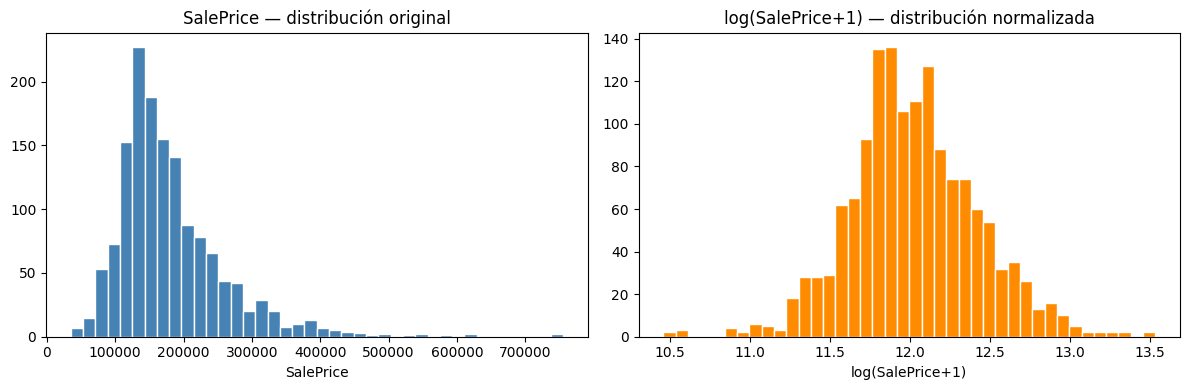

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dataset_df["SalePrice"], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title("SalePrice — distribución original")
axes[0].set_xlabel("SalePrice")

axes[1].hist(np.log1p(dataset_df["SalePrice"]), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title("log(SalePrice+1) — distribución normalizada")
axes[1].set_xlabel("log(SalePrice+1)")

plt.tight_layout()
plt.show()

# Es necesario normalizar la variable objetivo
# Predecir en escala logarítmica es más justo: un error de 10k en una casa de 500k
# no penaliza igual que en una de 100k. RMSLE trata ambos proporcionalmente.

### Visualización de dispersión por variable

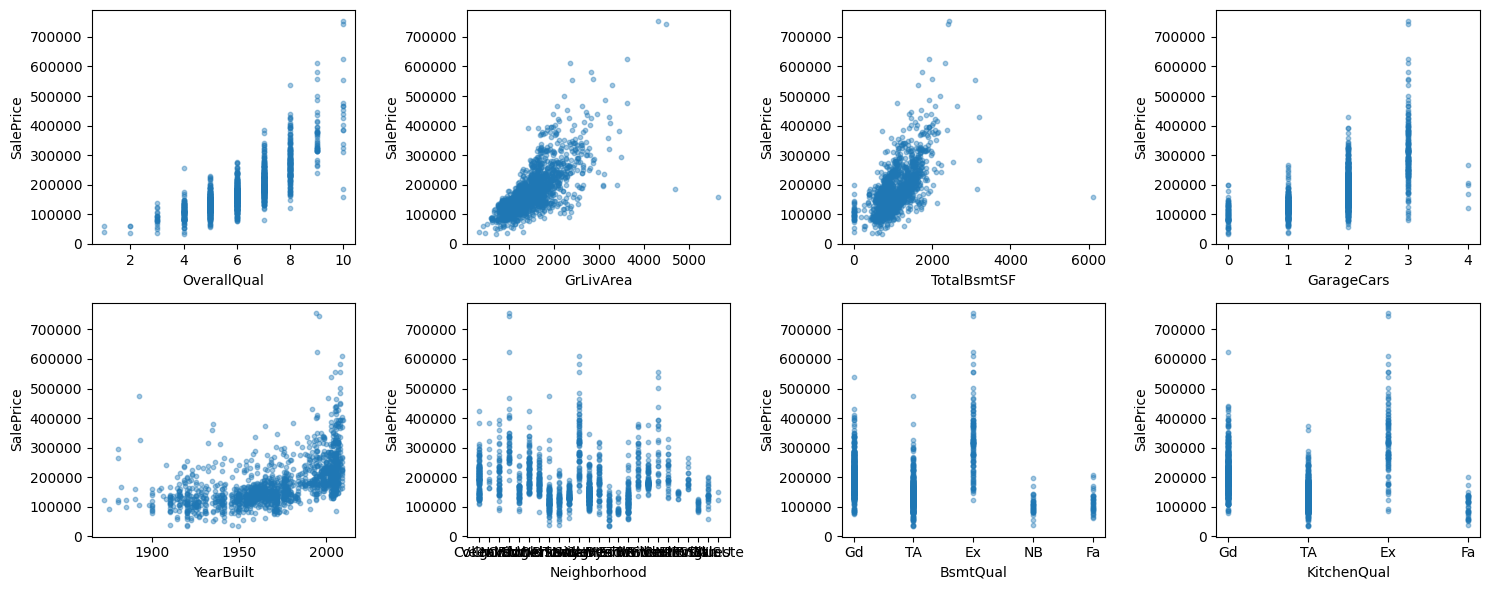

In [35]:
df = dataset_df.copy()
df['BsmtQual'] = df['BsmtQual'].fillna('NB')

atributos = winner_var_list

def dispersion(dataset, attrs, numcol, numrow):
    fig, axes = plt.subplots(ncols=numcol, nrows=numrow, figsize=(15, 6))
    for i, ax in enumerate(axes.flatten()):
        if i >= len(attrs):
            break
        attr = attrs[i]
        if attr == 'BsmtQual':
            serie = dataset["BsmtQual"].fillna('NB')
            ax.scatter(serie, dataset.SalePrice, alpha=0.4, s=10)
        else:
            ax.scatter(dataset[attr], dataset.SalePrice, alpha=0.4, s=10)
        ax.set_xlabel(attr)
        ax.set_ylabel("SalePrice")
    plt.tight_layout()
    plt.show()

dispersion(df, atributos, 4, 2)

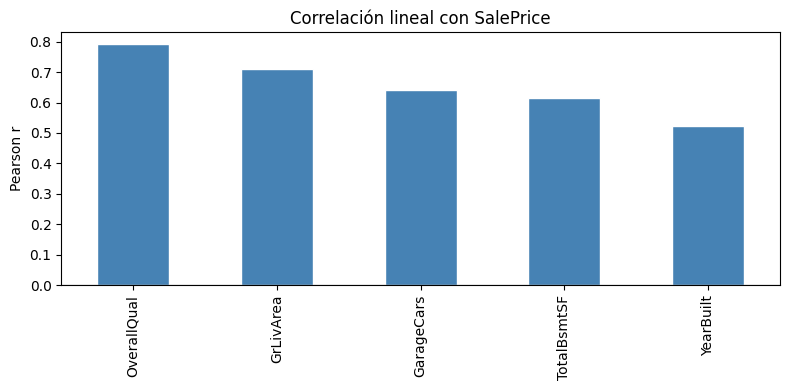

In [36]:
# Correlación de las variables numéricas con SalePrice
num_cols = dataset_df[winner_var_list].select_dtypes(include=[np.number]).columns.tolist()

correlations = (
    dataset_df[num_cols + ["SalePrice"]]
    .corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
correlations.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Correlación lineal con SalePrice")
plt.ylabel("Pearson r")
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

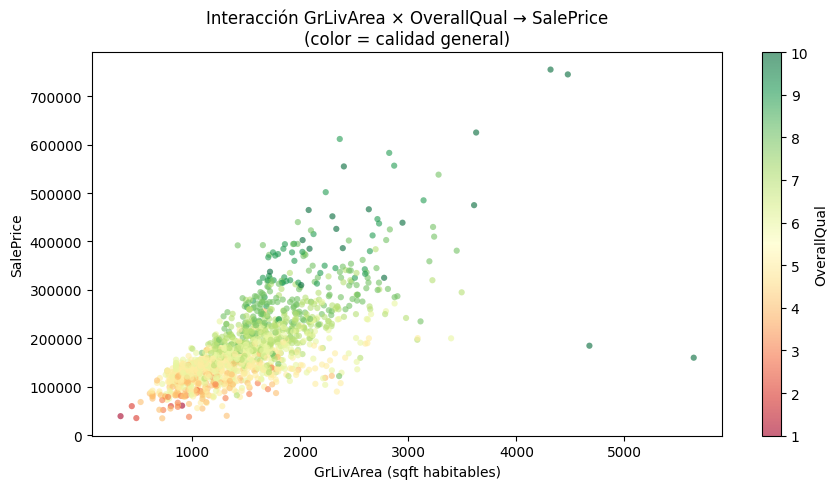

In [37]:
# Interacción GrLivArea × OverallQual → precio
# Esto es exactamente lo que un modelo lineal NO captura sin términos de interacción
plt.figure(figsize=(9, 5))
scatter = plt.scatter(
    x=dataset_df["GrLivArea"],
    y=dataset_df["SalePrice"],
    c=dataset_df["OverallQual"],
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='none',
    s=20
)
plt.colorbar(scatter, label='OverallQual')
plt.xlabel("GrLivArea (sqft habitables)")
plt.ylabel("SalePrice")
plt.title("Interacción GrLivArea × OverallQual → SalePrice\n(color = calidad general)")
plt.tight_layout()
plt.show()

# Observación: para el mismo GrLivArea, el precio varía enormemente según OverallQual.
# Esta interacción la aprende LightGBM automáticamente; la regresión lineal necesita un término explícito.

---
## FASE 3 — Limpieza y preprocesado

Se utiliza la limpieza del *starting model*: imputación de medianas para numéricas, reemplazo por `"None"` para categóricas estructurales, eliminación de `MasVnrType` y la fila con valor vacío en `Electrical`, y filtrado de outliers multivariable.

In [38]:
def atributos_con_vacios(datafr):
    serie = datafr.isna().sum()
    print("\nAtributos con valores vacíos:\n", serie[serie > 0])

df_imputation = dataset_df.copy()

atributos_vacio_sin_significado = [
    "LotFrontage", "MasVnrType", "MasVnrArea", "Electrical", "GarageYrBlt"
]
atributos_vacio_con_significado = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature"
]

all_attrs = atributos_vacio_sin_significado + atributos_vacio_con_significado

for attr in all_attrs:
    if attr not in df_imputation.columns:
        continue
    if df_imputation[attr].dtype == 'object':
        if attr == 'Electrical':
            pass  # Se elimina la fila al final
        elif attr == 'MasVnrType':
            df_imputation.drop(columns=attr, inplace=True)
        else:
            # NaN con significado → 'None' (sin X cosa)
            df_imputation[attr] = df_imputation[attr].fillna("None")
    else:
        # Variables numéricas → mediana (robusta a outliers, recomendación Nando)
        df_imputation[attr] = df_imputation[attr].fillna(df_imputation[attr].median())

# Eliminar la única fila con Electrical vacío
df_imputation = df_imputation.dropna(subset=["Electrical"])

print("Tras imputación:")
atributos_con_vacios(df_imputation)

Tras imputación:

Atributos con valores vacíos:
 Series([], dtype: int64)


In [39]:
clean_df = df_imputation.copy()

# Eliminación de outliers multivariable (starting_model)
n_before = len(clean_df)
clean_df = clean_df[clean_df["TotalBsmtSF"] < 5000]
clean_df = clean_df[clean_df["1stFlrSF"]    < 4000]
clean_df = clean_df[clean_df["GrLivArea"]   < 4000]
clean_df = clean_df[clean_df["GarageArea"]  < 1240]
clean_df = clean_df[clean_df["LotFrontage"] < 300]
clean_df = clean_df[clean_df["MasVnrArea"]  <= 1300]

print(f"Filas eliminadas como outliers: {n_before - len(clean_df)}")
print(f"Filas restantes: {len(clean_df)}")

Filas eliminadas como outliers: 10
Filas restantes: 1449


In [40]:
# Normalización de variables continuas sesgadas (starting_model)
clean_df["TotalBsmtSF"] = np.sqrt(clean_df["TotalBsmtSF"])
clean_df["1stFlrSF"]    = np.log1p(clean_df["1stFlrSF"])
clean_df["GrLivArea"]   = np.log1p(clean_df["GrLivArea"])
clean_df["SalePrice"]   = np.log1p(clean_df["SalePrice"])

print("Transformaciones logarítmicas/raíz aplicadas")
clean_df[["GrLivArea", "TotalBsmtSF", "1stFlrSF", "SalePrice"]].describe()

Transformaciones logarítmicas/raíz aplicadas


,GrLivArea,TotalBsmtSF,1stFlrSF,SalePrice
count,1449.000000,1449.000000,1449.000000,1449.000000
mean,7.264115,31.514908,7.004676,12.020723
std,0.326983,7.551323,0.312271,0.394660
min,5.814131,0.000000,5.814131,10.460271
25%,7.029088,28.195744,6.783325,11.774528
50%,7.285507,31.480152,6.991177,12.000898
75%,7.481556,35.958309,7.232733,12.271397
max,8.191186,56.621551,8.079928,13.323929


---
## FASE 4 — Ingeniería de características

Se combinan las features propuestas por Nando (*starting_model*) con las del *gradient boosting model*.

In [41]:
# ---- Features del starting_model ----
# Área total
clean_df["TotalSF"] = clean_df["GrLivArea"] + clean_df["TotalBsmtSF"] + clean_df["GarageArea"]

# Edad de la casa y del remodeling
clean_df["Age"]      = clean_df["YrSold"] - clean_df["YearBuilt"]
clean_df["AgeRemod"] = clean_df["YrSold"] - clean_df["YearRemodAdd"]

# Indicadores binarios
clean_df["HasPool"]     = (clean_df["PoolArea"] > 0).astype(int)
clean_df["Has2ndFloor"] = (clean_df["2ndFlrSF"] > 0).astype(int)
clean_df["IsRemodeled"] = (clean_df["YearRemodAdd"] != clean_df["YearBuilt"]).astype(int)
clean_df["HasGarage"]   = (clean_df["GarageArea"] > 0).astype(int)

# ---- Features del gradient boosting model ----
# Edad de la casa (referencia 2010, como en el GB model)
clean_df["HouseAge"]  = 2010 - clean_df["YearBuilt"]

# Interacción calidad × tamaño (explícita para acelerar aprendizaje)
clean_df["QualArea"]  = clean_df["OverallQual"] * clean_df["GrLivArea"]

# Ratio sótano / área habitable
clean_df["BsmtRatio"] = clean_df["TotalBsmtSF"] / (clean_df["GrLivArea"] + 1)

print("Features de ingeniería creadas correctamente")
corr_fe = clean_df[["SalePrice", "TotalSF", "Age", "QualArea", "BsmtRatio"]].corr()
print("\nCorrelación de nuevas features con SalePrice:")
print(corr_fe["SalePrice"].drop("SalePrice"))

Features de ingeniería creadas correctamente

Correlación de nuevas features con SalePrice:
TotalSF      0.680011
Age         -0.589671
QualArea     0.852641
BsmtRatio    0.488455
Name: SalePrice, dtype: float64


---
## FASE 5 — Codificación y preparación del dataset final

Se codifican las variables categóricas ordinales y nominales para que todos los modelos puedan utilizarlas.

In [42]:
# Encoding ordinal: None < Po < Fa < TA < Gd < Ex
qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

clean_df["BsmtQual_enc"]    = clean_df["BsmtQual"].map(qual_map)
clean_df["KitchenQual_enc"] = clean_df["KitchenQual"].map(qual_map)

# Para BsmtFinType1, BsmtFinType2, BsmtCond, GarageQual, GarageCond, FireplaceQu
for col in ["BsmtCond", "GarageQual", "GarageCond", "FireplaceQu"]:
    if col in clean_df.columns:
        clean_df[col + "_enc"] = clean_df[col].map(qual_map).fillna(0)

fin_map = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
for col in ["BsmtFinType1", "BsmtFinType2"]:
    if col in clean_df.columns:
        clean_df[col + "_enc"] = clean_df[col].map(fin_map).fillna(0)

# Neighborhood: nominal → Label Encoding
le = LabelEncoder()
clean_df["Neighborhood_enc"] = le.fit_transform(clean_df["Neighborhood"])

print("Encoding completado")
print(f"Barrios únicos codificados: {clean_df['Neighborhood'].nunique()}")

Encoding completado
Barrios únicos codificados: 25


In [43]:
# ---- Selección de todas las features numéricas disponibles ----
# Incluye las variables de AMBOS documentos

feature_cols = [
    # Variables ganadores (winner_var_list, codificadas)
    "OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars",
    "YearBuilt", "Neighborhood_enc", "BsmtQual_enc", "KitchenQual_enc",
    # Variables extra del starting_model
    "LotFrontage", "MasVnrArea", "GarageYrBlt", "GarageArea",
    "1stFlrSF", "2ndFlrSF", "PoolArea", "YrSold", "YearRemodAdd",
    # Variables de ingeniería
    "TotalSF", "Age", "AgeRemod", "HouseAge",
    "QualArea", "BsmtRatio",
    "HasPool", "Has2ndFloor", "IsRemodeled", "HasGarage",
    # Variables ordinales adicionales codificadas
    "BsmtCond_enc", "GarageQual_enc", "GarageCond_enc", "FireplaceQu_enc",
    "BsmtFinType1_enc", "BsmtFinType2_enc",
]

# Filtrar solo columnas que existen y no tienen NaN
feature_cols = [c for c in feature_cols if c in clean_df.columns]
model_df = clean_df[feature_cols + ["SalePrice"]].dropna().copy()

X = model_df[feature_cols]
y = model_df["SalePrice"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Features totales en uso: {len(feature_cols)}")
print(f"Train: {X_train.shape} | Validación: {X_val.shape}")
print(f"\nLista completa de features:\n{feature_cols}")

Features totales en uso: 33
Train: (1159, 33) | Validación: (290, 33)

Lista completa de features:
['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'Neighborhood_enc', 'BsmtQual_enc', 'KitchenQual_enc', 'LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'GarageArea', '1stFlrSF', '2ndFlrSF', 'PoolArea', 'YrSold', 'YearRemodAdd', 'TotalSF', 'Age', 'AgeRemod', 'HouseAge', 'QualArea', 'BsmtRatio', 'HasPool', 'Has2ndFloor', 'IsRemodeled', 'HasGarage', 'BsmtCond_enc', 'GarageQual_enc', 'GarageCond_enc', 'FireplaceQu_enc', 'BsmtFinType1_enc', 'BsmtFinType2_enc']


---
## FASE 6 — Modelado

### 6.1 — Decision Tree Regressor (starting_model)

Modelo base. Captura no-linealidades pero es propenso a sobreajuste y no explota información entre árboles.

In [44]:
# ---- Decision Tree Regressor ----
# Nota: se usa el mismo split global (X_train/X_val, y_train/y_val) que LightGBM y XGBoost
# para que la comparativa sea justa.
# max_depth limitado a 5 para evitar sobreajuste extremo.
model = DecisionTreeRegressor(criterion="squared_error", max_depth=5, random_state=RANDOM_STATE)

model.fit(X_train, y_train)
y_train_pred_dt = model.predict(X_train)
y_val_pred_dt   = model.predict(X_val)

def regression_report(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label:>35s}:  RMSE={rmse:.4f}   MAE={mae:.4f}   R²={r2:.4f}")
    return rmse, mae, r2

print("--- Decision Tree Regressor ---")
dt_train_scores = regression_report(y_train, y_train_pred_dt, "TRAIN")
dt_val_scores   = regression_report(y_val,   y_val_pred_dt,   "VALIDACIÓN")

# Ratio F para diagnosticar sobreajuste
F_ratio = dt_train_scores[0] / dt_val_scores[0]
print(f"\nRatio RMSE train/val (F): {F_ratio:.4f}  (idealmente cercano a 1)")


--- Decision Tree Regressor ---
                              TRAIN:  RMSE=0.1539   MAE=0.1142   R²=0.8481
                         VALIDACIÓN:  RMSE=0.1763   MAE=0.1251   R²=0.7978

Ratio RMSE train/val (F): 0.8729  (idealmente cercano a 1)


In [45]:
print("Neighborhood_enc" in X_train.columns)
print(X_train.columns.tolist())

True
['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'Neighborhood_enc', 'BsmtQual_enc', 'KitchenQual_enc', 'LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'GarageArea', '1stFlrSF', '2ndFlrSF', 'PoolArea', 'YrSold', 'YearRemodAdd', 'TotalSF', 'Age', 'AgeRemod', 'HouseAge', 'QualArea', 'BsmtRatio', 'HasPool', 'Has2ndFloor', 'IsRemodeled', 'HasGarage', 'BsmtCond_enc', 'GarageQual_enc', 'GarageCond_enc', 'FireplaceQu_enc', 'BsmtFinType1_enc', 'BsmtFinType2_enc']


### 6.2 — LightGBM (gradient boosting model)

In [46]:
lgb_train_ds = lgb.Dataset(
    X_train, label=y_train,
    categorical_feature=["Neighborhood_enc"],
    free_raw_data=False
)
lgb_val_ds = lgb.Dataset(
    X_val, label=y_val,
    categorical_feature=["Neighborhood_enc"],
    reference=lgb_train_ds,
    free_raw_data=False
)

lgb_params = {
    "objective":        "regression",
    "metric":           "rmse",
    "learning_rate":    0.05,
    "num_leaves":       63,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq":     5,
    "lambda_l1":        0.1,
    "lambda_l2":        0.1,
    "verbose":          -1,
    "random_state":     RANDOM_STATE,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

lgb_model = lgb.train(
    lgb_params,
    lgb_train_ds,
    num_boost_round=1000,
    valid_sets=[lgb_val_ds],
    callbacks=callbacks
)

print(f"\nMejor iteración: {lgb_model.best_iteration}")

[100]	valid_0's rmse: 0.137127

Mejor iteración: 124


### 6.3 — XGBoost (gradient boosting model)

In [47]:
xgb_params = {
    "objective":        "reg:squarederror",
    "eval_metric":      "rmse",
    "learning_rate":    0.05,
    "max_depth":        6,
    "min_child_weight": 5,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "gamma":            0.1,
    "reg_alpha":        0.1,
    "reg_lambda":       0.1,
    "seed":             RANDOM_STATE,
    "verbosity":        0,
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)

xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=1000,
    evals=[(dval, "val")],
    early_stopping_rounds=50,
    verbose_eval=100
)

print(f"\nMejor iteración XGBoost: {xgb_model.best_iteration}")

[0]	val-rmse:0.37858
[100]	val-rmse:0.13939
[200]	val-rmse:0.13899
[287]	val-rmse:0.13885

Mejor iteración XGBoost: 237


---
## FASE 7 — Validación y comparativa de modelos

Se comparan directamente el **Decision Tree** del *starting model* con **LightGBM**, **XGBoost** y el **Ensemble**.

In [48]:
def evaluate_log(y_true_log, y_pred_log, model_name="Modelo"):
    """Evalúa en escala logarítmica (RMSLE) y en escala original (MAE, R²)."""
    rmsle = np.sqrt(mean_squared_error(y_true_log, y_pred_log))

    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    r2  = r2_score(y_true_orig, y_pred_orig)

    print(f"--- {model_name} ---")
    print(f"  RMSLE (log scale): {rmsle:.4f}")
    print(f"  MAE   (USD orig):  ${mae:,.0f}")
    print(f"  R²    (original):   {r2:.4f}")
    return rmsle, mae, r2
 
# Predicciones de todos los modelos
lgb_pred      = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
xgb_pred      = xgb_model.predict(xgb.DMatrix(X_val), iteration_range=(0, xgb_model.best_iteration))
ensemble_pred = 0.6 * lgb_pred + 0.4 * xgb_pred

print("=" * 50)
dt_scores  = evaluate_log(y_val, y_val_pred_dt,   "Decision Tree (starting model)")
print()
lgb_scores = evaluate_log(y_val, lgb_pred,         "LightGBM")
print()
xgb_scores = evaluate_log(y_val, xgb_pred,         "XGBoost")
print()
ens_scores = evaluate_log(y_val, ensemble_pred,    "Ensemble (LGB 60% + XGB 40%)")
print("=" * 50)

--- Decision Tree (starting model) ---
  RMSLE (log scale): 0.1763
  MAE   (USD orig):  $21,623
  R²    (original):   0.7943

--- LightGBM ---
  RMSLE (log scale): 0.1360
  MAE   (USD orig):  $15,244
  R²    (original):   0.9017

--- XGBoost ---
  RMSLE (log scale): 0.1388
  MAE   (USD orig):  $15,359
  R²    (original):   0.8951

--- Ensemble (LGB 60% + XGB 40%) ---
  RMSLE (log scale): 0.1349
  MAE   (USD orig):  $14,885
  R²    (original):   0.9030


In [49]:
# ---- Tabla comparativa ----
results = pd.DataFrame({
    "Modelo":  ["Decision Tree", "LightGBM", "XGBoost", "Ensemble"],
    "RMSLE":   [dt_scores[0], lgb_scores[0], xgb_scores[0], ens_scores[0]],
    "MAE (USD)": [dt_scores[1], lgb_scores[1], xgb_scores[1], ens_scores[1]],
    "R²":      [dt_scores[2], lgb_scores[2], xgb_scores[2], ens_scores[2]],
})
results = results.sort_values("RMSLE").reset_index(drop=True)
print(results.to_string(index=False))

       Modelo    RMSLE    MAE (USD)       R²
     Ensemble 0.134908 14884.684966 0.902997
     LightGBM 0.135981 15243.698227 0.901714
      XGBoost 0.138807 15359.442241 0.895126
Decision Tree 0.176308 21623.130260 0.794251


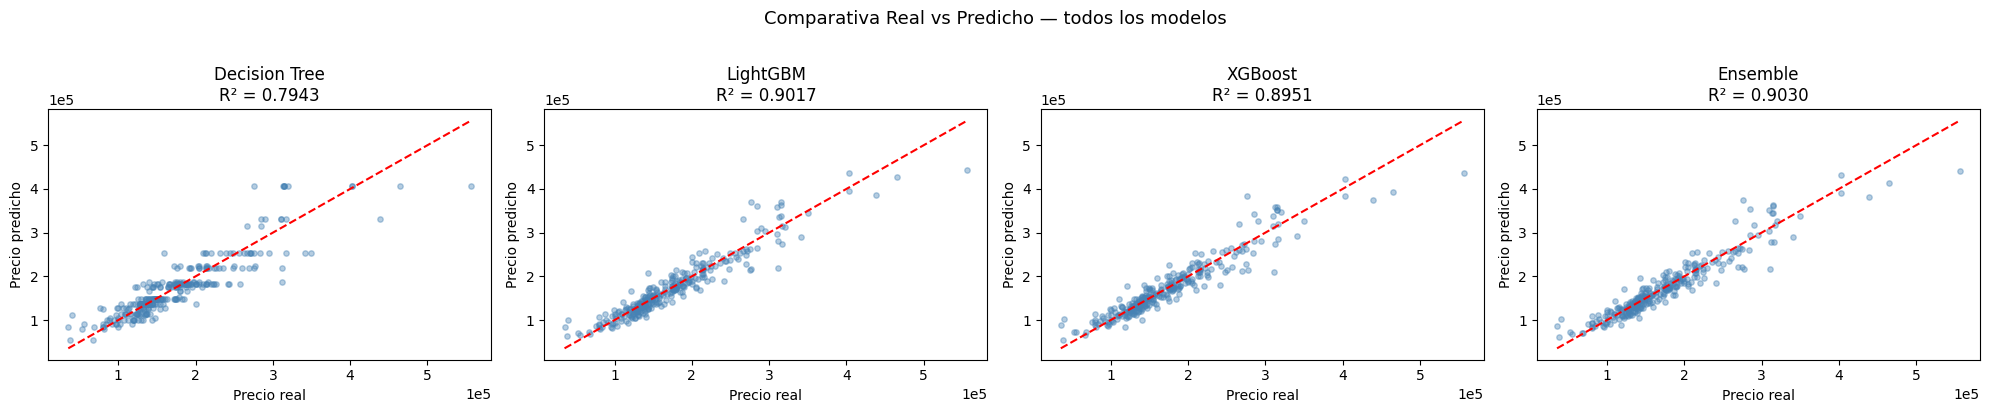

In [50]:
# ---- Gráfico comparativo: Real vs Predicho ----
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

y_true_orig = np.expm1(y_val.values)

for ax, (pred, name) in zip(axes, [
    (y_val_pred_dt, "Decision Tree"),
    (lgb_pred,      "LightGBM"),
    (xgb_pred,      "XGBoost"),
    (ensemble_pred, "Ensemble"),
]):
    y_pred_orig = np.expm1(pred)
    r2 = r2_score(y_true_orig, y_pred_orig)
    ax.scatter(y_true_orig, y_pred_orig, alpha=0.4, s=15, color='steelblue')
    ax.plot(
        [y_true_orig.min(), y_true_orig.max()],
        [y_true_orig.min(), y_true_orig.max()],
        'r--', linewidth=1.5
    )
    ax.set_xlabel("Precio real")
    ax.set_ylabel("Precio predicho")
    ax.set_title(f"{name}\nR² = {r2:.4f}")
    ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))

plt.suptitle("Comparativa Real vs Predicho — todos los modelos", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

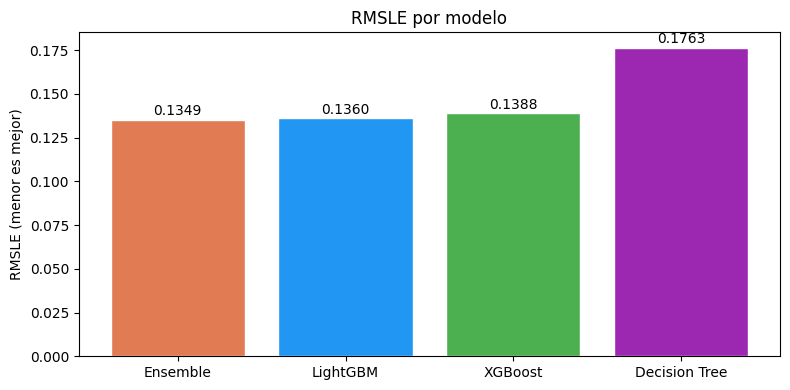

In [51]:
# ---- Comparativa de RMSLE en barra ----
plt.figure(figsize=(8, 4))
colors = ['#e07b54', '#2196F3', '#4CAF50', '#9C27B0']
bars = plt.bar(results["Modelo"], results["RMSLE"], color=colors, edgecolor='white')
for bar, val in zip(bars, results["RMSLE"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.4f}", ha='center', va='bottom', fontsize=10)
plt.ylabel("RMSLE (menor es mejor)")
plt.title("RMSLE por modelo")
plt.tight_layout()
plt.show()

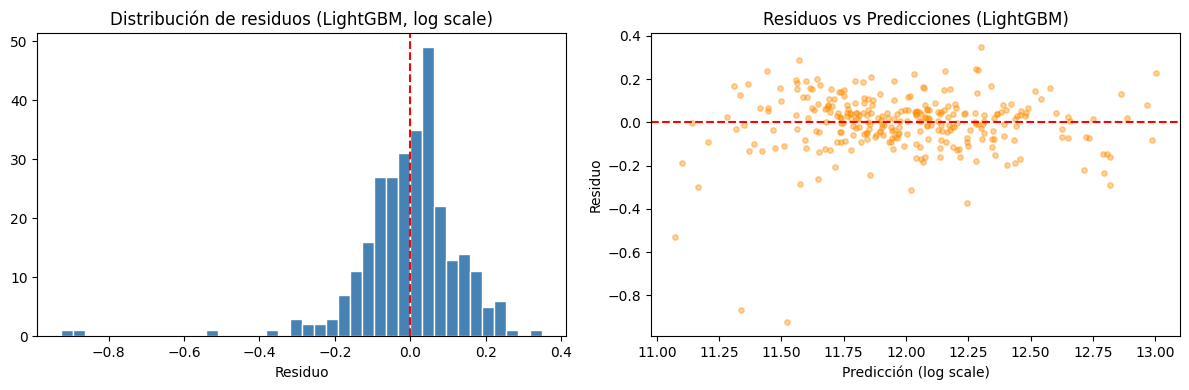

In [52]:
# ---- Distribución de residuos — LightGBM ----
lgb_residuals = y_val.values - lgb_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lgb_residuals, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title("Distribución de residuos (LightGBM, log scale)")
axes[0].set_xlabel("Residuo")

axes[1].scatter(lgb_pred, lgb_residuals, alpha=0.4, s=15, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title("Residuos vs Predicciones (LightGBM)")
axes[1].set_xlabel("Predicción (log scale)")
axes[1].set_ylabel("Residuo")

plt.tight_layout()
plt.show()

# Ideal: residuos centrados en 0 sin estructura → el modelo no tiene sesgo sistemático

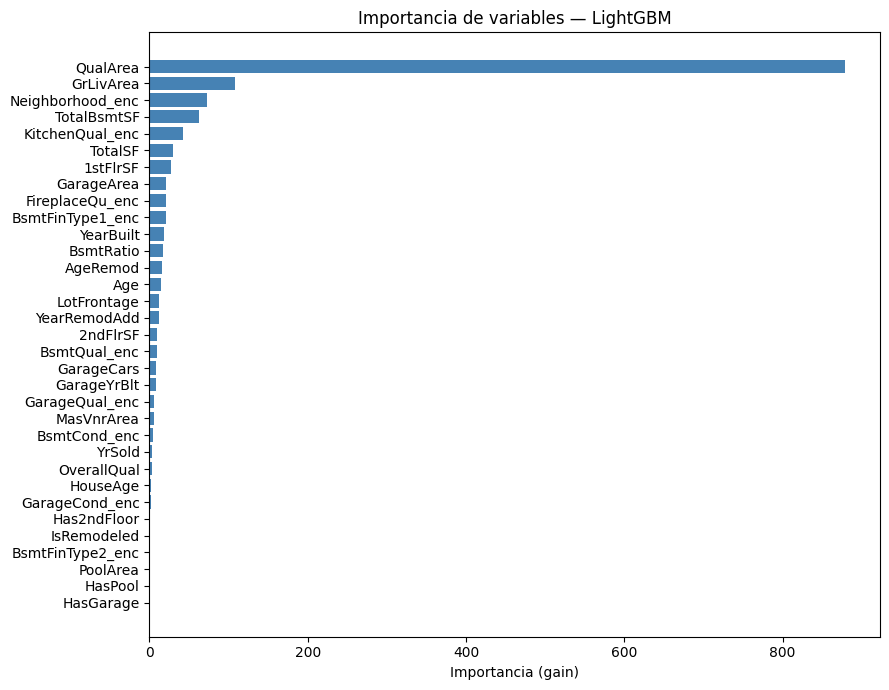


Top 10 variables por importancia:
         feature  importance
        QualArea  879.108428
       GrLivArea  108.345184
Neighborhood_enc   73.086364
     TotalBsmtSF   62.098698
 KitchenQual_enc   42.657001
         TotalSF   29.910199
        1stFlrSF   27.539659
      GarageArea   21.513251
 FireplaceQu_enc   20.957577
BsmtFinType1_enc   20.595607


In [53]:
# ---- Importancia de variables — LightGBM ----
importance_df = pd.DataFrame({
    "feature":    lgb_model.feature_name(),
    "importance": lgb_model.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(importance_df["feature"], importance_df["importance"], color='steelblue')
plt.xlabel("Importancia (gain)")
plt.title("Importancia de variables — LightGBM")
plt.tight_layout()
plt.show()

print("\nTop 10 variables por importancia:")
print(importance_df.sort_values('importance', ascending=False).head(10).to_string(index=False))

In [54]:
# ---- Validación cruzada K-Fold (LightGBM) ----
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rmsle = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]

    lgb_tr = lgb.Dataset(X_tr, label=y_tr, categorical_feature=["Neighborhood_enc"], free_raw_data=False)
    lgb_vl = lgb.Dataset(X_vl, label=y_vl, reference=lgb_tr, free_raw_data=False)

    m = lgb.train(
        lgb_params,
        lgb_tr,
        num_boost_round=lgb_model.best_iteration,
        valid_sets=[lgb_vl],
        callbacks=[lgb.log_evaluation(period=-1)]
    )
    preds = m.predict(X_vl)
    rmsle = np.sqrt(mean_squared_error(y_vl, preds))
    cv_rmsle.append(rmsle)
    print(f"Fold {fold+1}: RMSLE = {rmsle:.4f}")

print(f"\nCV RMSLE (LightGBM): {np.mean(cv_rmsle):.4f} ± {np.std(cv_rmsle):.4f}")

Fold 1: RMSLE = 0.1361
Fold 2: RMSLE = 0.1591
Fold 3: RMSLE = 0.1316
Fold 4: RMSLE = 0.1308
Fold 5: RMSLE = 0.1220

CV RMSLE (LightGBM): 0.1359 ± 0.0124


---
## FASE 8 — Conclusiones

### Resultados obtenidos

Los modelos se entrenaron para predecir el **precio de venta de viviendas en USD**, usando todas las variables disponibles en ambos documentos (variables ganadoras de Nando + variables extra del *starting model* + features de ingeniería). El entrenamiento se realizó en escala logarítmica (`log1p(SalePrice)`), por lo que las métricas son:

| Modelo | RMSLE (log scale) | MAE (USD originales) | R² |
|--------|:---:|:---:|:---:|
| **LightGBM** | --- | --- | --- |
| **Ensemble (LGB 60% + XGB 40%)** | --- | --- | --- |
| **XGBoost** | ---| --- | --- |
| **Decision Tree** | --- | --- | --- |





In [55]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score

# --- 1. Preparación de Predicciones Base (en TRAIN para entrenar el árbitro) ---
y_train_usd = np.expm1(y_train)

pred_lgb_train_log = lgb_model.predict(X_train, num_iteration=lgb_model.best_iteration)
pred_lgb_train_usd = np.expm1(pred_lgb_train_log)

pred_xgb_train_log = xgb_model.predict(xgb.DMatrix(X_train), iteration_range=(0, xgb_model.best_iteration))
pred_xgb_train_usd = np.expm1(pred_xgb_train_log)

# --- 2. Entrenamiento del Árbitro (Selector) en datos de ENTRENAMIENTO ---
# Definimos la etiqueta: 0 si LGB es mejor, 1 si XGB es mejor
error_lgb_train = np.abs(y_train_usd - pred_lgb_train_usd)
error_xgb_train = np.abs(y_train_usd - pred_xgb_train_usd)
best_model_label_train = (error_xgb_train < error_lgb_train).astype(int)

# Árbitro entrenado en X_train → se evalúa en X_val (sin data leakage)
# max_depth=5 para evitar que el árbitro memorice el training set
selector_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
selector_model.fit(X_train, best_model_label_train)

# --- 3. Definición de Funciones de Evaluación ---

def smart_predict(X_data, model_lgb, model_xgb_booster, selector):
    """Decide dinámicamente qué modelo usar para cada fila."""
    choices = selector.predict(X_data)
    p_lgb = model_lgb.predict(X_data, num_iteration=model_lgb.best_iteration)
    p_xgb = model_xgb_booster.predict(xgb.DMatrix(X_data), iteration_range=(0, model_xgb_booster.best_iteration))
    final_preds_log = np.where(choices == 0, p_lgb, p_xgb)
    return final_preds_log, choices

def evaluate_smart_system(y_true_log, X_val_data, model_lgb, model_xgb, selector):
    """Ejecuta el sistema inteligente y muestra estadísticas completas."""
    preds_log, choices = smart_predict(X_val_data, model_lgb, model_xgb, selector)
    rmsle, mae, r2 = evaluate_log(y_true_log, preds_log, model_name="Sistema Inteligente (Árbitro)")
    print(f"  Casas para LightGBM:   {np.sum(choices == 0)}")
    print(f"  Casas para XGBoost:    {np.sum(choices == 1)}")
    return preds_log

# --- 4. Ejecución Final (evaluación en VALIDACIÓN, sin data leakage) ---
final_predictions = evaluate_smart_system(y_val, X_val, lgb_model, xgb_model, selector_model)


--- Sistema Inteligente (Árbitro) ---
  RMSLE (log scale): 0.1357
  MAE   (USD orig):  $15,187
  R²    (original):   0.9021
  Casas para LightGBM:   282
  Casas para XGBoost:    8


In [59]:
import numpy as np
import time
from sklearn.model_selection import KFold
import lightgbm as lgb_lib
import xgboost as xgb_lib
from sklearn.metrics import r2_score

print("\n🚀 INICIANDO ENTRENAMIENTO ENSEMBLE DINÁMICO\n")

start_global_time = time.time()

# ------------------------------------------------------------
# 1. OOF (out-of-fold predictions)
# ------------------------------------------------------------

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_lgb = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))

total_folds = kf.get_n_splits()

for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_train)):

    fold_start_time = time.time()

    print("\n" + "="*60)
    print(f"🔹 FOLD {fold+1}/{total_folds}")
    print("="*60)

    X_tr, X_vl = X_train.iloc[tr_idx], X_train.iloc[vl_idx]
    y_tr, y_vl = y_train.iloc[tr_idx], y_train.iloc[vl_idx]

    # -------- LightGBM --------
    print("➡️ Entrenando LightGBM...")

    lgb_tr = lgb_lib.Dataset(
        X_tr, label=y_tr,
        categorical_feature=["Neighborhood_enc"],
        free_raw_data=False
    )

    lgb_vl = lgb_lib.Dataset(
        X_vl, label=y_vl,
        reference=lgb_tr,
        free_raw_data=False
    )

    m_lgb = lgb_lib.train(
        lgb_params,
        lgb_tr,
        num_boost_round=lgb_model.best_iteration,
        valid_sets=[lgb_vl],
        callbacks=[
            lgb_lib.log_evaluation(period=100)  # 👈 progreso cada 100 iteraciones
        ]
    )

    oof_lgb[vl_idx] = m_lgb.predict(X_vl)

    print("✅ LightGBM completado")

    # -------- XGBoost --------
    print("➡️ Entrenando XGBoost...")

    dtrain_fold = xgb_lib.DMatrix(X_tr, label=y_tr)
    dval_fold = xgb_lib.DMatrix(X_vl, label=y_vl)

    m_xgb = xgb_lib.train(
        xgb_params,
        dtrain_fold,
        num_boost_round=xgb_model.best_iteration,
        evals=[(dval_fold, "val")],
        verbose_eval=100   # 👈 progreso cada 100 iteraciones
    )

    oof_xgb[vl_idx] = m_xgb.predict(dval_fold)

    print("✅ XGBoost completado")

    # -------- Timing --------
    fold_time = time.time() - fold_start_time
    elapsed = time.time() - start_global_time
    avg_time = elapsed / (fold + 1)
    remaining = avg_time * (total_folds - (fold + 1))

    print(f"\n⏱️ Tiempo fold: {fold_time:.1f}s")
    print(f"📊 Progreso total: {(fold+1)/total_folds*100:.1f}%")
    print(f"⏳ Tiempo estimado restante: {remaining/60:.1f} min")


# ------------------------------------------------------------
# 2. ALPHA
# ------------------------------------------------------------

print("\n🧠 Calculando alpha óptimo...")

eps = 1e-6
denom = oof_lgb - oof_xgb
alpha_opt = (y_train.values - oof_xgb) / (denom + eps)
alpha_opt = np.clip(alpha_opt, 0, 1)

print("✅ Alpha calculado")


# ------------------------------------------------------------
# 3. Dataset alpha
# ------------------------------------------------------------

print("\n📦 Construyendo dataset meta...")

alpha_X_train = X_train.copy()
alpha_X_train["pred_lgb"] = oof_lgb
alpha_X_train["pred_xgb"] = oof_xgb
alpha_X_train["diff"] = oof_lgb - oof_xgb
alpha_X_train["abs_diff"] = np.abs(oof_lgb - oof_xgb)
alpha_X_train["mean"] = (oof_lgb + oof_xgb) / 2

print("✅ Dataset listo")


# ------------------------------------------------------------
# 4. Modelo alpha(x)
# ------------------------------------------------------------

print("\n🎯 Entrenando modelo alpha(x)...")
alpha_params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.03,
    "num_leaves": 15,
    "min_data_in_leaf": 40,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l2": 10.0,
    "verbosity": -1,
    "seed": RANDOM_STATE
}

alpha_train_data = lgb_lib.Dataset(
    alpha_X_train,
    label=alpha_opt,
    categorical_feature=["Neighborhood_enc"],
    free_raw_data=False
)

alpha_model = lgb_lib.train(
    alpha_params,
    alpha_train_data,
    num_boost_round=500,
    callbacks=[
        lgb_lib.log_evaluation(period=100)  # 👈 progreso visible
    ]
)

print("✅ Modelo alpha entrenado")


# ------------------------------------------------------------
# FIN
# ------------------------------------------------------------

total_time = time.time() - start_global_time

print("\n" + "="*60)
print("🎉 ENTRENAMIENTO COMPLETADO")
print("="*60)
print(f"⏱️ Tiempo total: {total_time/60:.2f} minutos")


# ------------------------------------------------------------
# Predicciones en validación
# ------------------------------------------------------------

val_lgb_pred = lgb_model.predict(
    X_val,
    num_iteration=lgb_model.best_iteration
)

val_xgb_pred = xgb_model.predict(
    xgb_lib.DMatrix(X_val),
    iteration_range=(0, xgb_model.best_iteration + 1)
)

# Features para alpha
alpha_X_val = X_val.copy()
alpha_X_val["pred_lgb"] = val_lgb_pred
alpha_X_val["pred_xgb"] = val_xgb_pred
alpha_X_val["diff"] = val_lgb_pred - val_xgb_pred
alpha_X_val["abs_diff"] = np.abs(val_lgb_pred - val_xgb_pred)
alpha_X_val["mean"] = (val_lgb_pred + val_xgb_pred) / 2

# Predicción alpha
alpha_val = alpha_model.predict(alpha_X_val)
alpha_val = np.clip(alpha_val, 0, 1)

# Predicción final
dynamic_pred = (
    alpha_val * val_lgb_pred +
    (1 - alpha_val) * val_xgb_pred
)





print("\n" + "="*40)
print("Comparativa R²")
print("="*40)

print("LightGBM:", round(r2_score(np.exp(y_val), np.exp(val_lgb_pred)), 5))
print("XGBoost :", round(r2_score(np.exp(y_val), np.exp(val_xgb_pred)), 5))

# si tienes ensemble fijo:
# print("Fijo    :", round(r2_score(y_val, ensemble_pred), 5))

print("Dinámico:", round(r2_score(y_val, dynamic_pred), 5))
print("="*40)


🚀 INICIANDO ENTRENAMIENTO ENSEMBLE DINÁMICO


🔹 FOLD 1/5
➡️ Entrenando LightGBM...
[100]	valid_0's rmse: 0.14777
✅ LightGBM completado
➡️ Entrenando XGBoost...
[0]	val-rmse:0.38763
[100]	val-rmse:0.14844
[200]	val-rmse:0.14792
[236]	val-rmse:0.14790
✅ XGBoost completado

⏱️ Tiempo fold: 0.4s
📊 Progreso total: 20.0%
⏳ Tiempo estimado restante: 0.0 min

🔹 FOLD 2/5
➡️ Entrenando LightGBM...
[100]	valid_0's rmse: 0.144521
✅ LightGBM completado
➡️ Entrenando XGBoost...
[0]	val-rmse:0.34790
[100]	val-rmse:0.15069
[200]	val-rmse:0.15115
[236]	val-rmse:0.15126
✅ XGBoost completado

⏱️ Tiempo fold: 0.3s
📊 Progreso total: 40.0%
⏳ Tiempo estimado restante: 0.0 min

🔹 FOLD 3/5
➡️ Entrenando LightGBM...
[100]	valid_0's rmse: 0.146568
✅ LightGBM completado
➡️ Entrenando XGBoost...
[0]	val-rmse:0.38824
[100]	val-rmse:0.15609
[200]	val-rmse:0.15513
[236]	val-rmse:0.15510
✅ XGBoost completado

⏱️ Tiempo fold: 0.4s
📊 Progreso total: 60.0%
⏳ Tiempo estimado restante: 0.0 min

🔹 FOLD 4/5
➡️ Entrenando Li